<a href="https://colab.research.google.com/github/cpt0/data201-labs/blob/main/Week2_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

college = pd.read_csv("/content/drive/MyDrive/DATA 201/Datasets/College.csv")

In [3]:
college2 = pd.read_csv("/content/drive/MyDrive/DATA 201/Datasets/College.csv", index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'},
                           axis=1)
college3 = college3.set_index('College')

In [4]:
college = college3

In [5]:
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
college[["Enroll", "Accept"]].describe()

,Enroll,Accept
count,777.000000,777.000000
mean,779.972973,2018.804376
std,929.176190,2451.113971
min,35.000000,72.000000
25%,242.000000,604.000000
50%,434.000000,1110.000000
75%,902.000000,2424.000000
max,6392.000000,26330.000000


In [7]:
col = college[['Top10perc', 'Apps', 'Enroll']]
col.head()

,Top10perc,Apps,Enroll
College,,,
Abilene Christian University,23,1660,721
Adelphi University,16,2186,512
Adrian College,22,1428,336
Agnes Scott College,60,417,137
Alaska Pacific University,16,193,55


array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

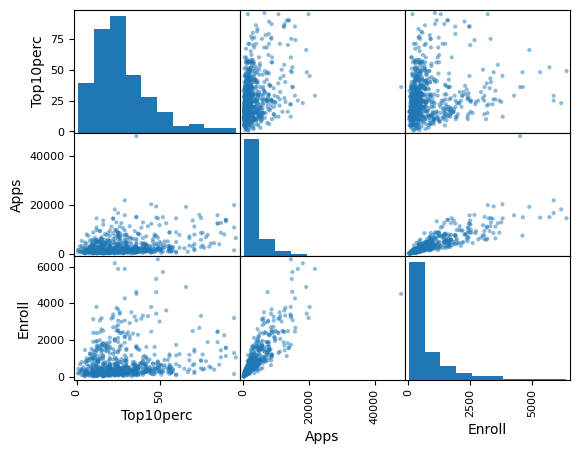

In [8]:
pd.plotting.scatter_matrix(col[['Top10perc', 'Apps', 'Enroll']])

In [9]:
import matplotlib.pyplot as plt

In [10]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


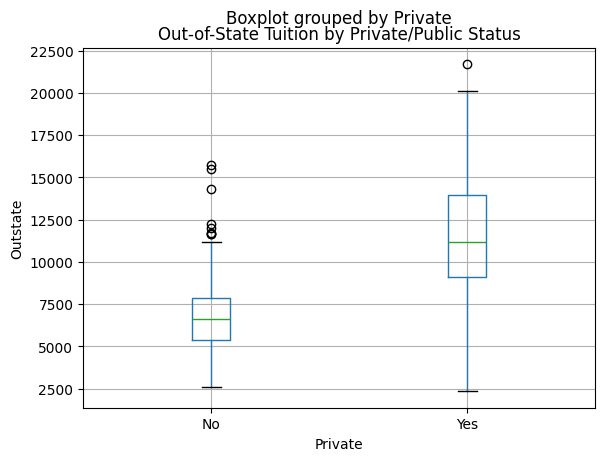

In [11]:
college.boxplot(column='Outstate', by='Private')
plt.title('Out-of-State Tuition by Private/Public Status')
plt.xlabel('Private')
plt.ylabel('Outstate')
plt.show()

Private schools have noticeably higher out-of-state tuition than public schools, and the spread (box height) is wider for private schools too.

### (f) Creating the Elite variable

In [16]:

college['Elite'] = pd.cut(college['Top10perc'],
                           [0, 50, 100],
                           labels=['No', 'Yes'])
college['Elite'].value_counts()

,count
Elite,
No,699
Yes,78


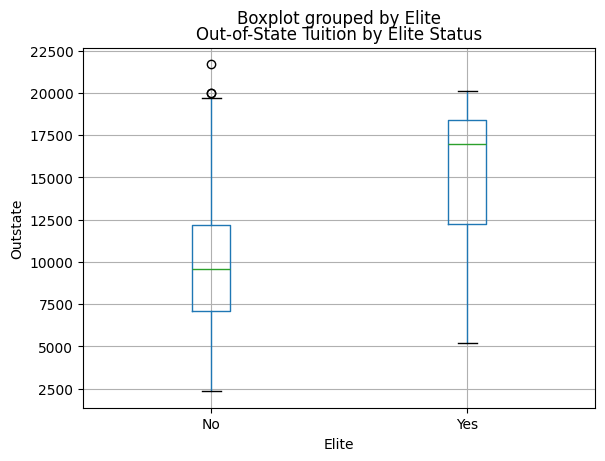

In [17]:
college.boxplot(column='Outstate', by='Elite')
plt.title('Out-of-State Tuition by Elite Status')
plt.xlabel('Elite')
plt.ylabel('Outstate')
plt.show()

array([[<Axes: title={'center': 'Apps'}>,
        <Axes: title={'center': 'Accept'}>],
       [<Axes: title={'center': 'Enroll'}>,
        <Axes: title={'center': 'Outstate'}>]], dtype=object)

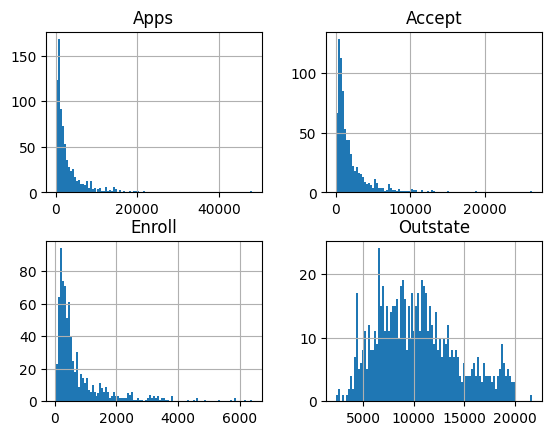

In [18]:
college[['Apps', 'Accept', 'Enroll', 'Outstate']].hist(bins=99)


Most colleges receive a modest number of applications, but a small number of schools receive a very large number, so Apps, Accept, and Enroll are all right-skewed.


## Question 9 — Auto dataset

Load the data the same way we did in Lab02, then clean up the `horsepower` column. As we found in the lab, the missing values in `horsepower` are stored as the character `"?"`, so `pandas` doesn't treat them as `NaN` until we fix that.

In [19]:
Auto = pd.read_csv("/content/drive/MyDrive/DATA 201/Datasets/Auto (1).csv")

# Fix the '?' placeholders in horsepower, same as in the lab
Auto['horsepower'] = Auto['horsepower'].replace('?', pd.NA)
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'])

# Make sure the missing values are actually removed from the data
Auto = Auto.dropna()
Auto.shape

(392, 9)

### (a) Quantitative vs. qualitative predictors

In [20]:
Auto.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
year,int64
origin,int64
name,object


- **Quantitative:** `mpg`, `displacement`, `horsepower`, `weight`, `acceleration`
- **Qualitative:** `cylinders`, `year`, `origin`, `name`

`cylinders`, `year`, and `origin` are stored as numbers, but they each only take a small number of distinct values that act like category labels (e.g. `origin` is really "USA/Europe/Japan" in disguise, like we saw in Lab02), so it makes more sense to treat them as qualitative rather than continuous measurements.

### (b) Range of each quantitative predictor

In [21]:
quant_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

auto_range = Auto[quant_cols].max() - Auto[quant_cols].min()
auto_range

,0
mpg,37.6
displacement,387.0
horsepower,184.0
weight,3527.0
acceleration,16.8


### (c) Mean and standard deviation of each quantitative predictor

In [22]:
Auto[quant_cols].mean()

,0
mpg,23.445918
displacement,194.411990
horsepower,104.469388
weight,2977.584184
acceleration,15.541327


In [23]:
Auto[quant_cols].std()

,0
mpg,7.805007
displacement,104.644004
horsepower,38.491160
weight,849.402560
acceleration,2.758864


### (d) Remove rows 10-85, then re-check range, mean, and standard deviation

In [24]:
# .iloc so we drop by position, matching "the 10th through 85th observations"
Auto_subset = Auto.drop(Auto.index[10:85])
Auto_subset.shape

(317, 9)

In [25]:
print('Range (max - min):')
print(Auto_subset[quant_cols].max() - Auto_subset[quant_cols].min())
print()
print('Mean:')
print(Auto_subset[quant_cols].mean())
print()
print('Standard deviation:')
print(Auto_subset[quant_cols].std())

Range (max - min):
mpg               35.6
displacement     387.0
horsepower       184.0
weight          3348.0
acceleration      16.3
dtype: float64

Mean:
mpg               24.374763
displacement     187.880126
horsepower       101.003155
weight          2938.854890
acceleration      15.704101
dtype: float64

Standard deviation:
mpg               7.872565
displacement    100.169973
horsepower       36.003208
weight          811.640668
acceleration      2.719913
dtype: float64


The range, mean, and standard deviation only shift slightly after removing those 75 rows, which suggests they weren't extreme outliers relative to the rest of the data set.

### (e) Investigate the predictors graphically

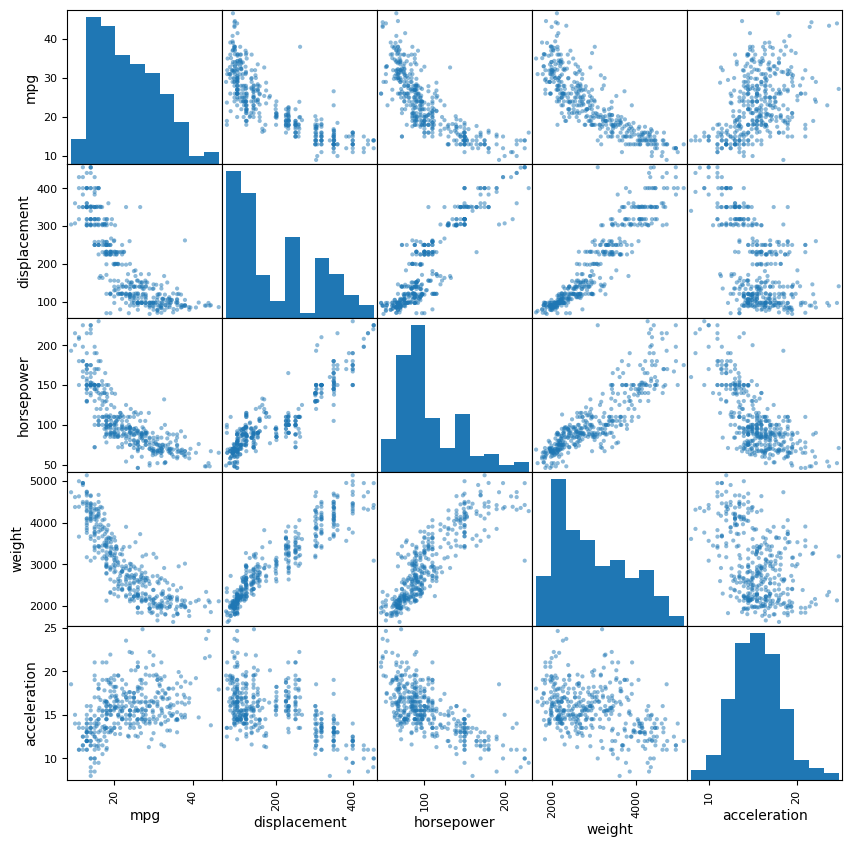

In [26]:
pd.plotting.scatter_matrix(Auto[quant_cols], figsize=(10, 10))
plt.show()

A few relationships stand out:
- `weight`, `displacement`, and `horsepower` all move together very closely — heavier cars tend to have bigger engines with more horsepower.
- `mpg` trends downward as `weight`, `displacement`, and `horsepower` increase.
- `acceleration` tends to be lower for heavier, higher-horsepower cars.

### (f) Do the plots suggest any variables are useful for predicting mpg?

Yes. In the scatterplot matrix above, `mpg` shows a clear negative relationship with `weight`, `displacement`, and `horsepower` — as any of those three go up, `mpg` tends to go down. `acceleration` has a weaker, positive relationship with `mpg`. This suggests `weight`, `displacement`, and `horsepower` would be the most useful predictors of `mpg`.

## Question 10 — Boston housing dataset

### (a) Load the Boston data set

In [27]:
!pip install ISLP -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.5 MB/s eta 0:00:00


In [31]:
from ISLP import load_data

Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### (b) Rows, columns, and what they represent

In [32]:
Boston.shape

(506, 13)

The data set has 506 rows and 13 columns. Each **row** is one suburb (town) of Boston. Each **column** is a variable measured for that suburb — things like the per-capita crime rate (`crim`), average number of rooms per home (`rm`), pupil/teacher ratio (`ptratio`), and the median value of owner-occupied homes (`medv`), which is often used as the variable we'd want to predict.

### (c) Pairwise scatterplots of the predictors

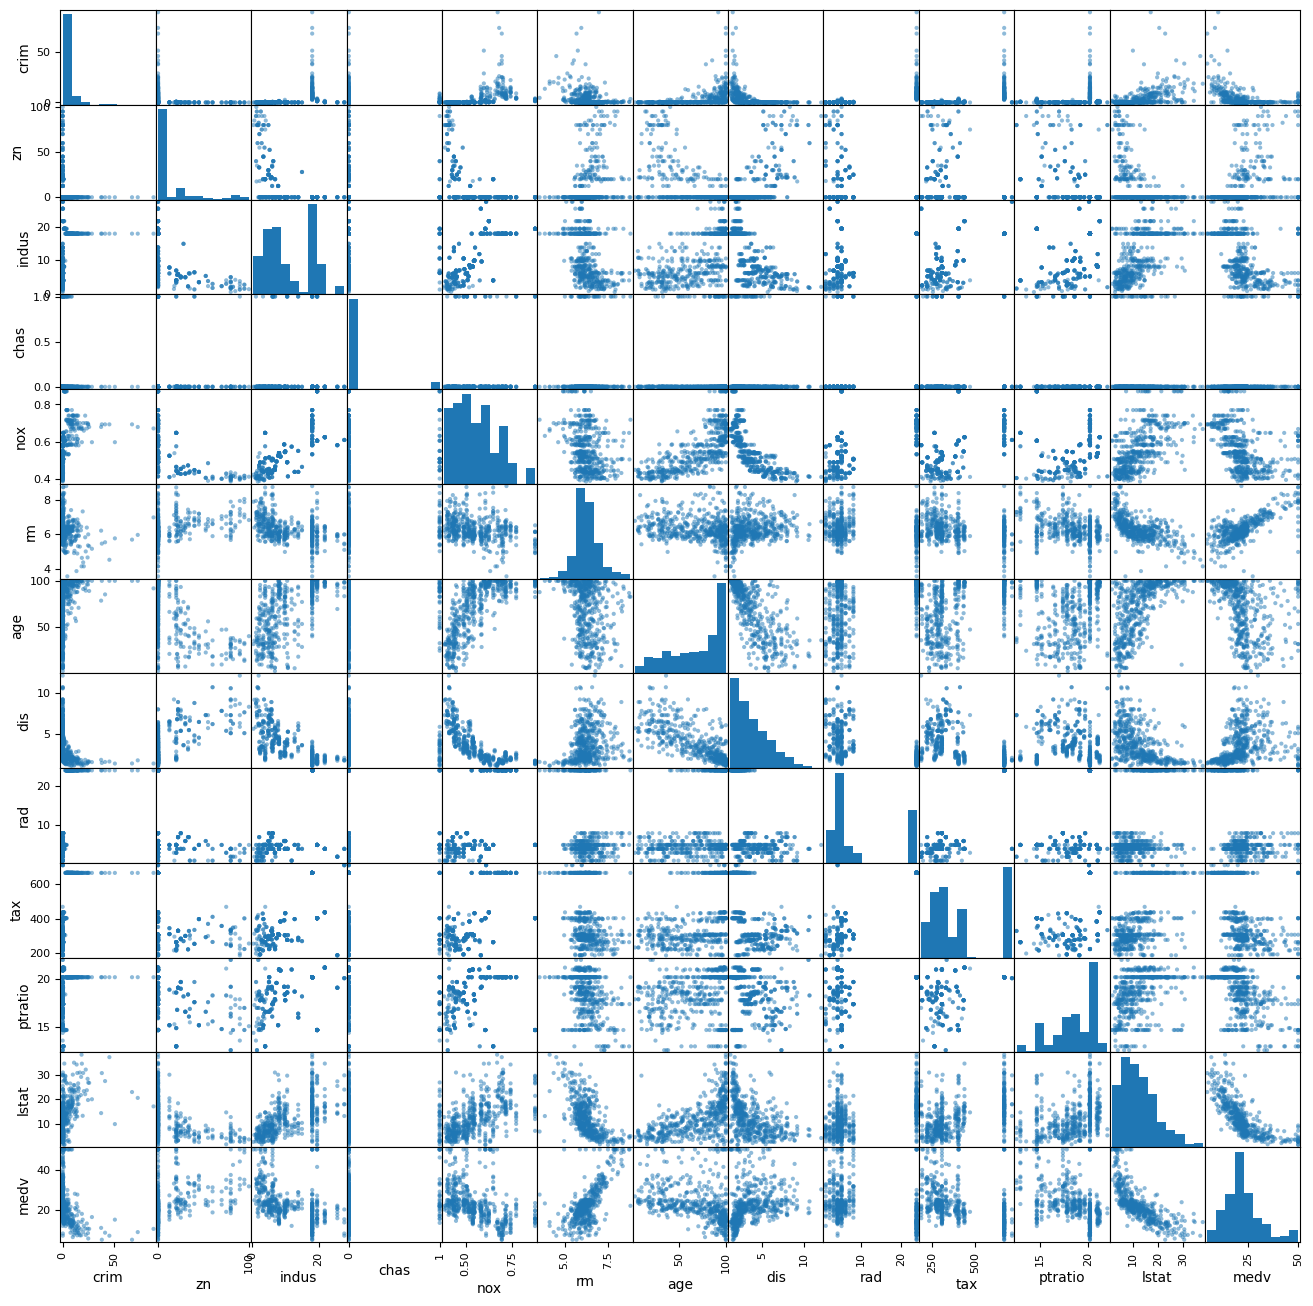

In [33]:
pd.plotting.scatter_matrix(Boston, figsize=(16, 16))
plt.show()

A few patterns are visible:
- `nox` (nitrogen oxide concentration) rises together with `indus` and `age`, which makes sense — older, more industrial areas tend to have more air pollution.
- `dis` (distance to employment centers) falls as `nox`, `indus`, and `age` rise — suburbs closer to the city center are more industrial and more polluted.
- `lstat` (percent lower-status population) has a clear negative relationship with `medv` (median home value) and with `rm` (rooms per home).

### (d) Are any predictors associated with per-capita crime rate?

Looking back at the scatter matrix from part (c): `rad` and `tax` both show an upward relationship with `crim` (suburbs with easier highway access and higher property taxes tend to have more crime), while `medv` shows a downward relationship (more expensive suburbs tend to have less crime). Most of the other predictors don't show an obvious pattern with `crim` in the scatter matrix.

`rad` (accessibility to radial highways) and `tax` (property tax rate) have the strongest positive correlation with `crim` — suburbs with easier highway access and higher tax rates tend to have higher crime rates. `medv` (median home value) has the strongest negative correlation — more expensive suburbs tend to have less crime.

### (e) Suburbs with particularly high crime, tax, or pupil-teacher ratios

In [34]:
Boston[['crim', 'tax', 'ptratio']].describe()

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


From the `describe()` output above:
- `crim` ranges from 0.006 all the way up to about 89 — the top end is far higher than the 75th percentile, so a small number of suburbs have unusually high crime rates compared to the rest.
- `tax` ranges from 187 to 711, and the mean/median sit well below the max, so there are also some suburbs with unusually high tax rates.
- `ptratio` has a much narrower range (12.6 to 22), so pupil-teacher ratios are fairly similar across suburbs compared to crime and tax rate.

`crim` has an enormous range — most suburbs have a crime rate under 4, but the worst suburb is above 88, so a small number of suburbs are far more dangerous than the rest. `tax` ranges from 187 to 711, with a cluster of suburbs sitting right at the top of that range (likely the same high-tax district). `ptratio` has a much narrower range (12.6 to 22), so pupil-teacher ratios are fairly similar across suburbs compared to crime and tax rate.

### (f) How many suburbs bound the Charles River?

In [35]:
Boston['chas'].value_counts()

,count
chas,
0,471
1,35


### (g) Median pupil-teacher ratio

In [36]:
# describe() already reports the median as the '50%' row, so we can just look it up
# from there instead of using a new function
ptratio_summary = Boston['ptratio'].describe()
ptratio_summary['50%']

np.float64(19.05)

### (h) Suburb with the lowest median home value

In [37]:
lowest_value = Boston['medv'].min()
lowest_value

5.0

To see the full row for that suburb, we can put a condition inside the brackets instead of a position — `Boston[condition]` keeps only the rows where the condition is `True`. It's the same bracket-indexing idea from Lab02 Part 3, just using a true/false test instead of a list of positions.

In [38]:
Boston[Boston['medv'] == lowest_value]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0


In [39]:
Boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


Comparing that suburb's row to the `describe()` output above: it has a very high crime rate and property tax rate relative to the rest of the data set, is fully industrial/high `lstat`, and near the low end for `dis` — consistent with it also having the lowest home values in the data set.

### (i) Suburbs averaging more than 7 or 8 rooms per dwelling

In [40]:
rooms_over_7 = pd.cut(Boston['rm'], [0, 7, 100], labels=['7 or fewer', 'more than 7'])
rooms_over_7.value_counts()

,count
rm,
7 or fewer,442
more than 7,64


In [41]:
rooms_over_8 = pd.cut(Boston['rm'], [0, 8, 100], labels=['8 or fewer', 'more than 8'])
rooms_over_8.value_counts()

,count
rm,
8 or fewer,493
more than 8,13


Only 13 suburbs average more than 8 rooms per dwelling — that's a small slice of the 506 total. Looking back at the scatter matrix in part (c), `rm` had a clear positive relationship with `medv`, so it makes sense that these high-`rm` suburbs are probably also on the higher end for home values.

Only a small number of suburbs (13) average more than 8 rooms per dwelling. Those suburbs tend to have lower crime rates and higher median home values than the overall data set, which fits — bigger homes tend to sit in wealthier, safer neighborhoods.